### Wymuszenie instalacji bibliotek ("%")

In [6]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Oryginalny zbiór danych

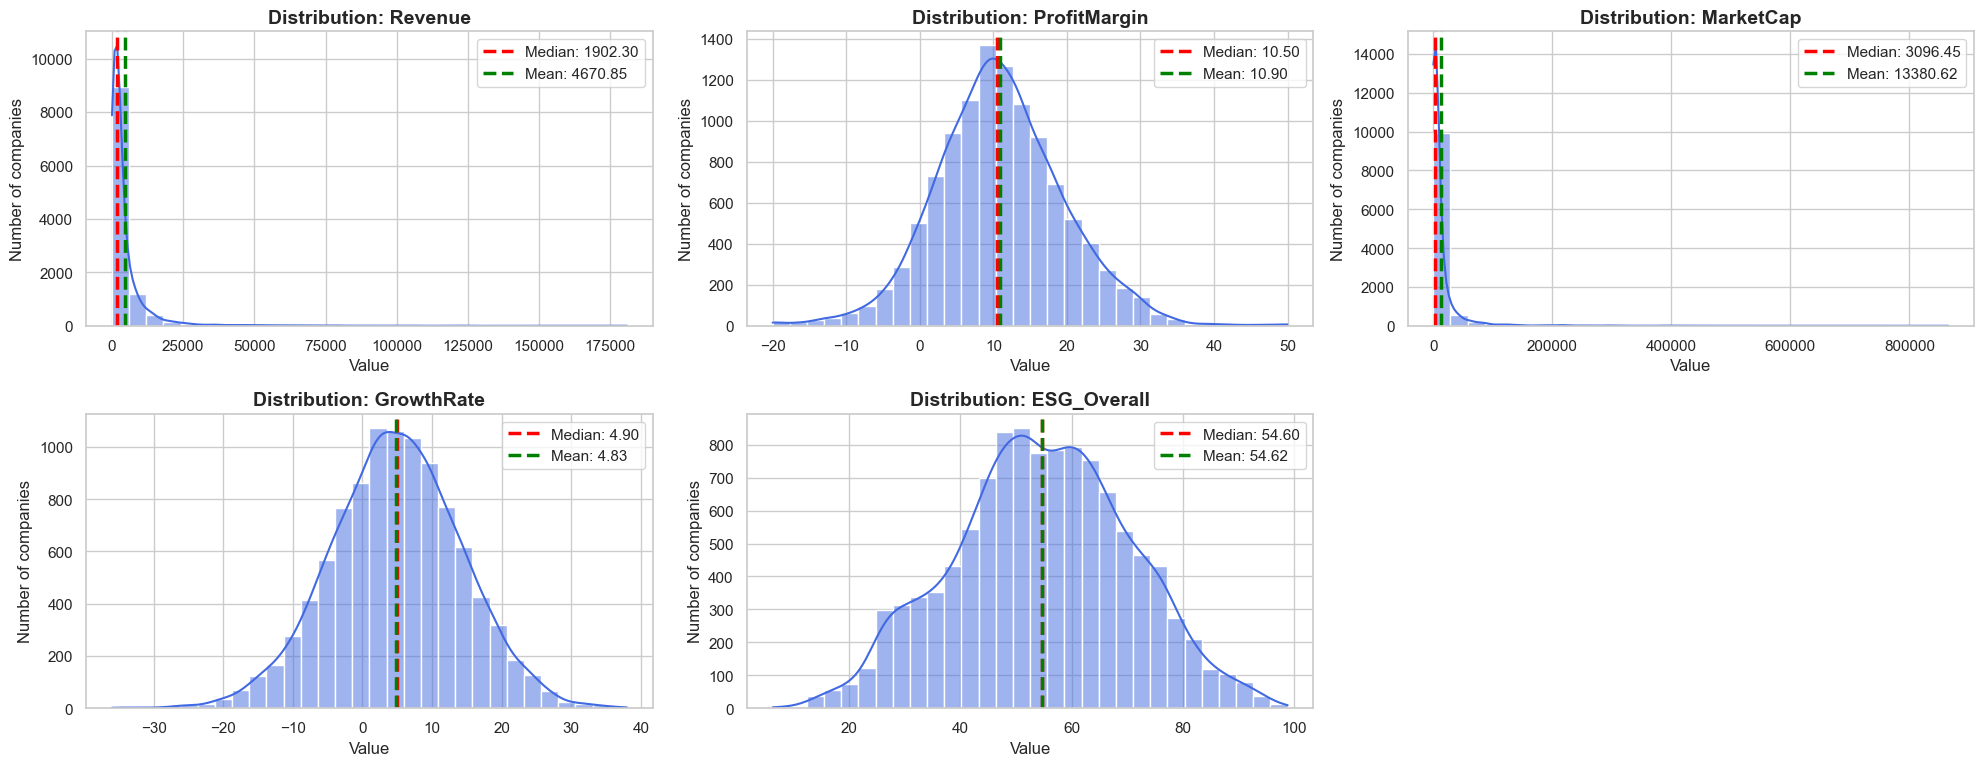

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

LOCAL_FOLDER = Path.cwd().parent / "local_folder"
dataPath = LOCAL_FOLDER / "company_esg_financial_dataset.csv"

sns.set_theme(style="whitegrid", palette="muted")

df_orig = pd.read_csv(dataPath)

num_cols = ['Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall']

plt.figure(figsize=(20, 15))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i) # Siatka 4 rzędy x 3 kolumny
    # Rysujemy histogram z linią gęstości (kde=True)
    sns.histplot(df_orig[col], kde=True, bins=30, color="royalblue")

    median_val = df_orig[col].median()
    mean_val = df_orig[col].mean()
    plt.axvline(median_val, color='red', linestyle='--', linewidth=2.5, label=f'Median: {median_val:.2f}')
    plt.axvline(mean_val, color='green', linestyle='--', linewidth=2.5, label=f'Mean: {mean_val:.2f}')
    
    # Kosmetyka wykresu
    plt.title(f'Distribution: {col}', fontsize=14, fontweight='bold')
    plt.xlabel('Value')
    plt.ylabel('Number of companies')

    plt.legend()

# Automatyczne dopasowanie odstępów i wyświetlenie
plt.tight_layout()
plt.show()

### Importy i wczytanie danych

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

dataPath = LOCAL_FOLDER / "aggregated_and_standarised_company_data.csv"

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv(dataPath)

CALCULATED_METRICS = ['PriceToSales', 'NetIncome', 'PriceToEarnings', 'Risk-AdjustedGrowth', 'Earnings-to-Growth', 'ESG_Signal-to-Noise']

WMA_columns = [col for col in df.columns if col.endswith('_WMA')]
cv_columns = [col for col in df.columns if col.endswith('_cv')]
slope_columns = [col for col in df.columns if col.endswith('slope')]
metrics_columns = [col for col in df.columns if col in CALCULATED_METRICS]

print(f"Read {len(df)} companies.")
print(f"Found {len(WMA_columns)} WMA columns, {len(cv_columns)} CV columns and {len(slope_columns)} slope columns.")
print(f"Found {len(metrics_columns)} metrics columns.")

Read 1000 companies.
Found 5 WMA columns, 5 CV columns and 5 slope columns.
Found 6 metrics columns.


### Rozkłady wartości średnich (Wskaźniki firmy)

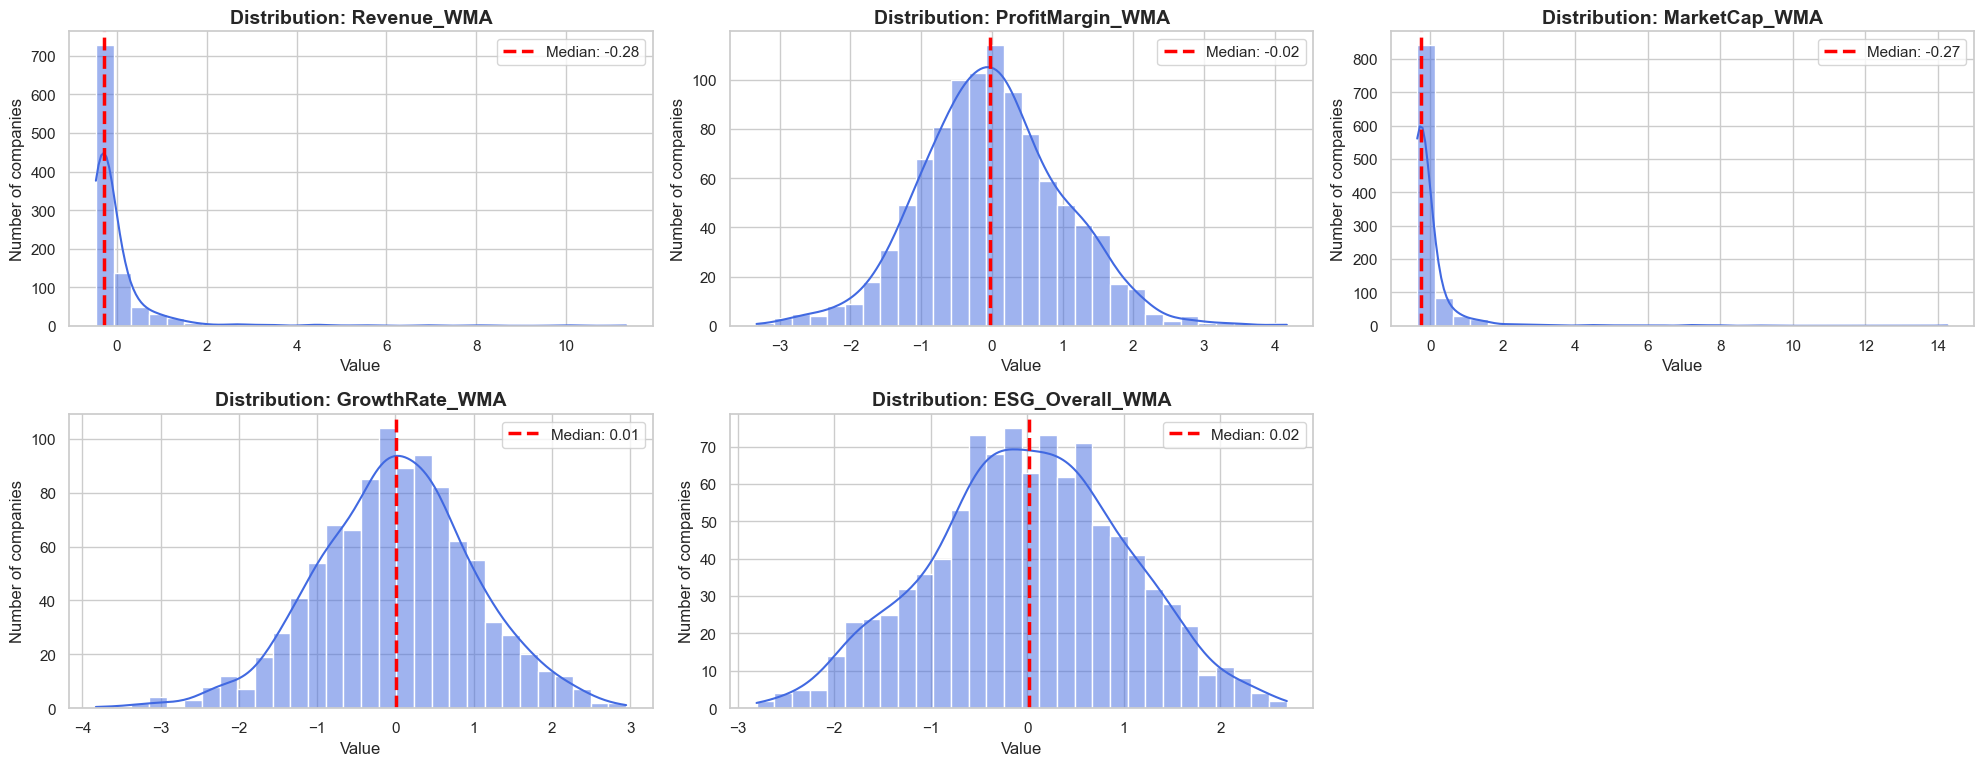

In [9]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(WMA_columns, 1):
    plt.subplot(4, 3, i) # Siatka 4 rzędy x 3 kolumny
    # Rysujemy histogram z linią gęstości (kde=True)
    sns.histplot(df[col], kde=True, bins=30, color="royalblue")

    median_val = df[col].median()
    plt.axvline(median_val, color='red', linestyle='--', linewidth=2.5, label=f'Median: {median_val:.2f}')
    
    # Kosmetyka wykresu
    plt.title(f'Distribution: {col}', fontsize=14, fontweight='bold')
    plt.xlabel('Value')
    plt.ylabel('Number of companies')

    plt.legend()

# Automatyczne dopasowanie odstępów i wyświetlenie
plt.tight_layout()
plt.show()

### Rozkłady zmienności / Ryzyka (Współczynnik CV)

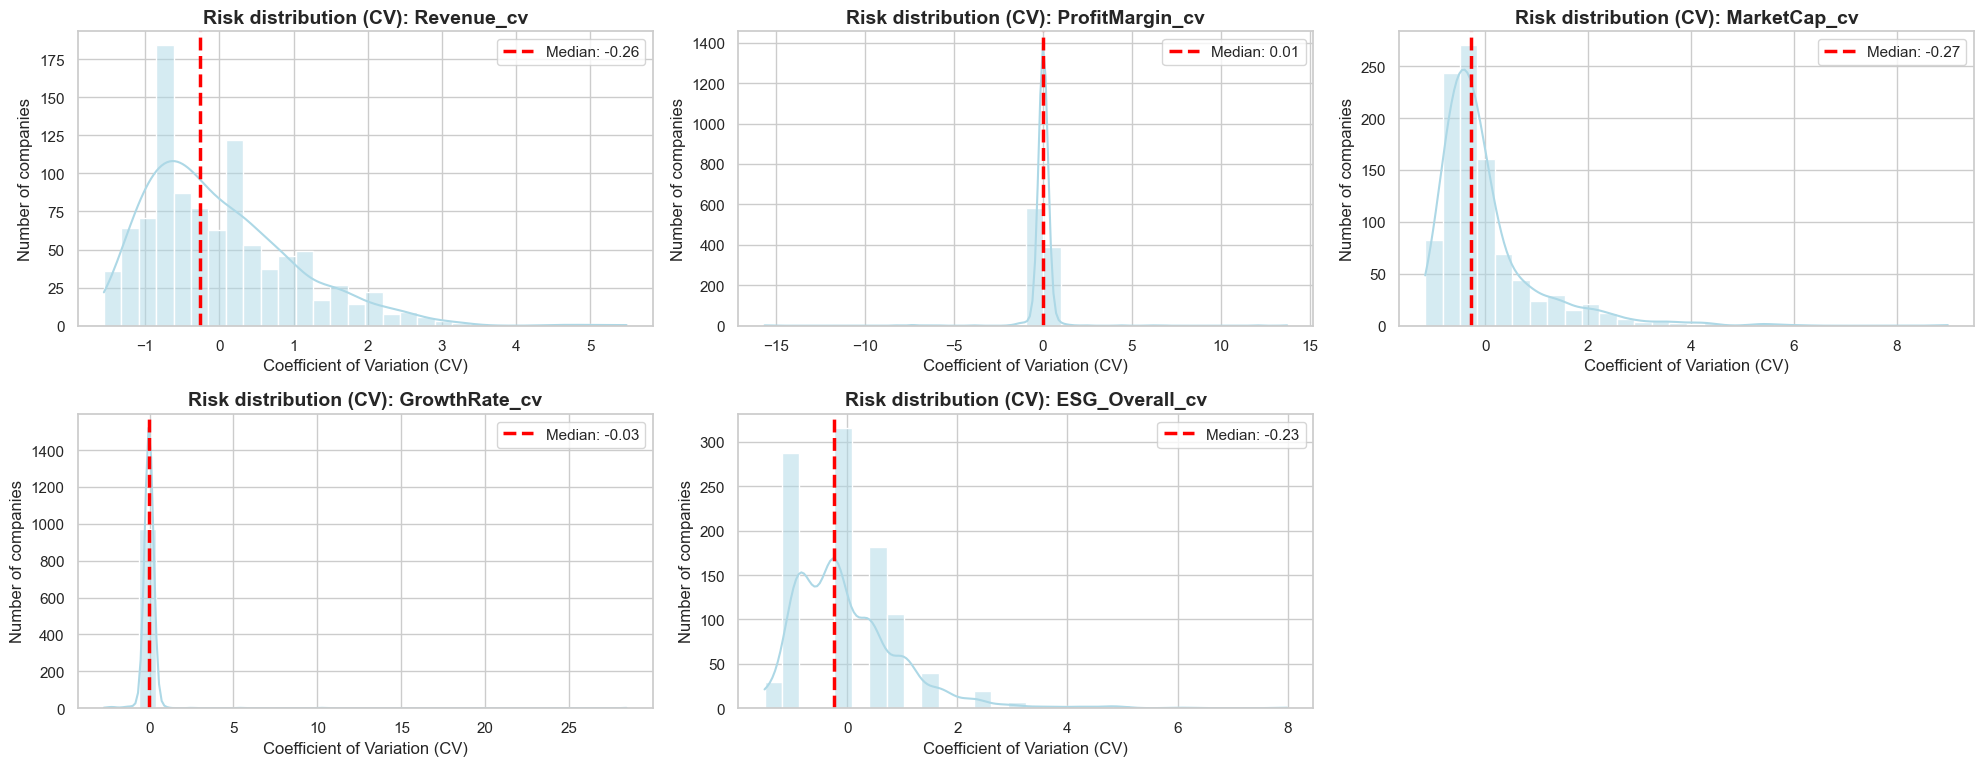

In [10]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(cv_columns, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color="lightblue")

    median_val = df[col].median()
    plt.axvline(median_val, color='red', linestyle='--', linewidth=2.5, label=f'Median: {median_val:.2f}')
    
    plt.title(f'Risk distribution (CV): {col}', fontsize=14, fontweight='bold')
    plt.xlabel('Coefficient of Variation (CV)')
    plt.ylabel('Number of companies')

    plt.legend()

plt.tight_layout()
plt.show()

## Rozkłady slope (współczynnik a w linii regresji) / tendencja metryki

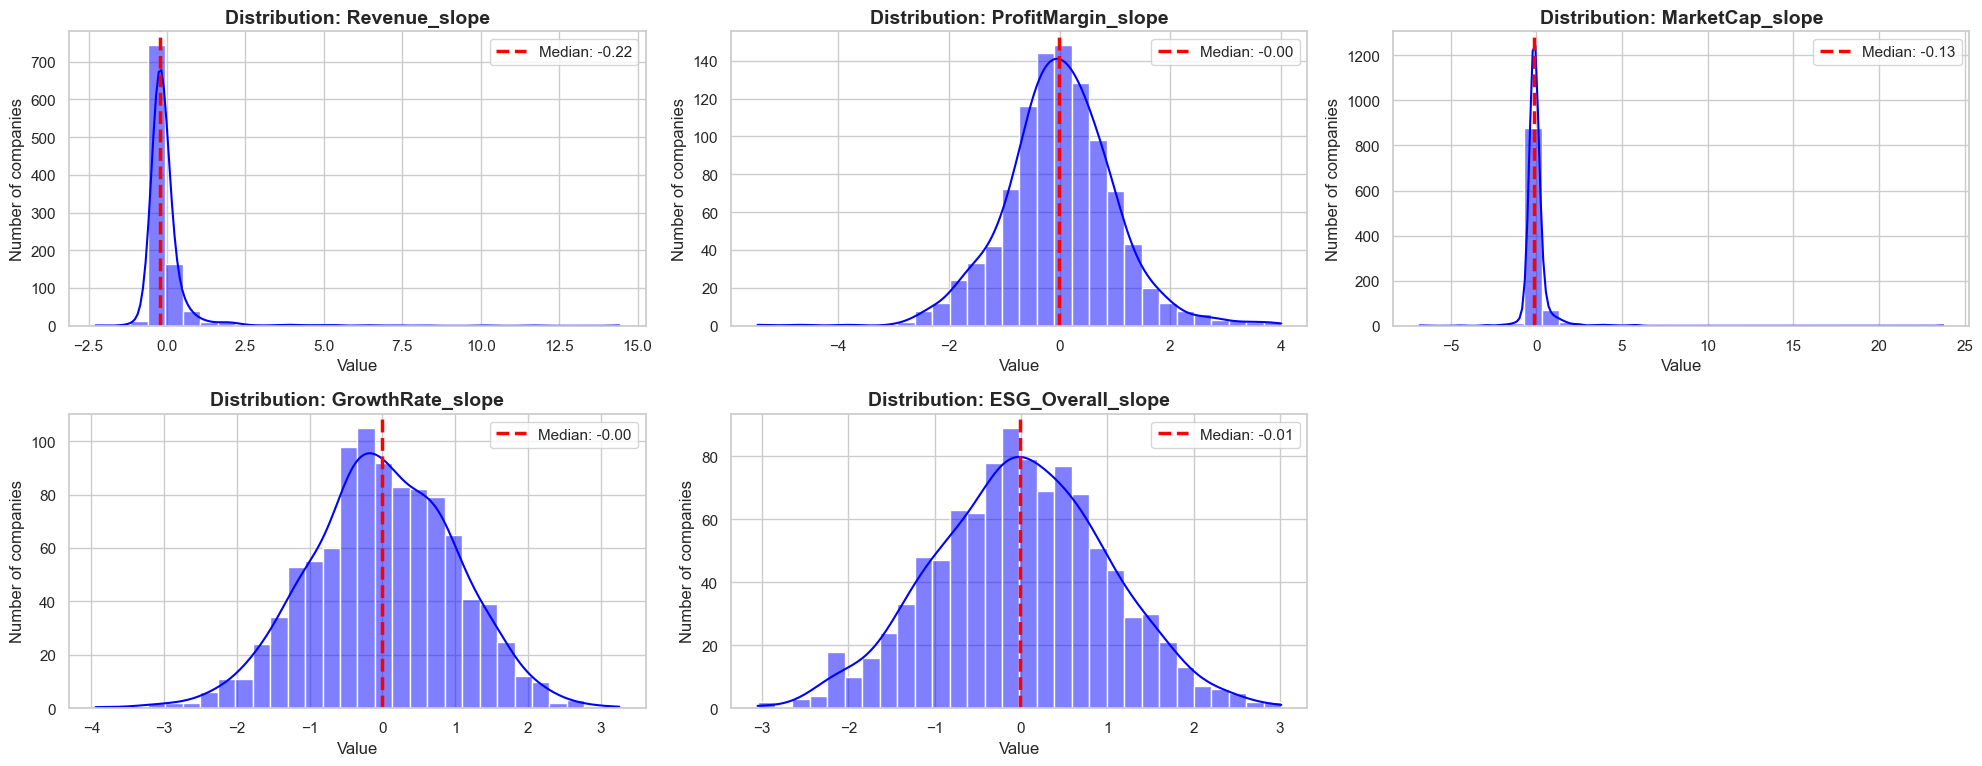

In [11]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(slope_columns, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color="blue")

    median_val = df[col].median()
    plt.axvline(median_val, color='red', linestyle='--', linewidth=2.5, label=f'Median: {median_val:.2f}')
    
    plt.title(f'Distribution: {col}', fontsize=14, fontweight='bold')
    plt.xlabel('Value')
    plt.ylabel('Number of companies')

    plt.legend()

plt.tight_layout()
plt.show()

### Rozkłady metryk wyliczanych (ostatnie kolumny w arkuszu)

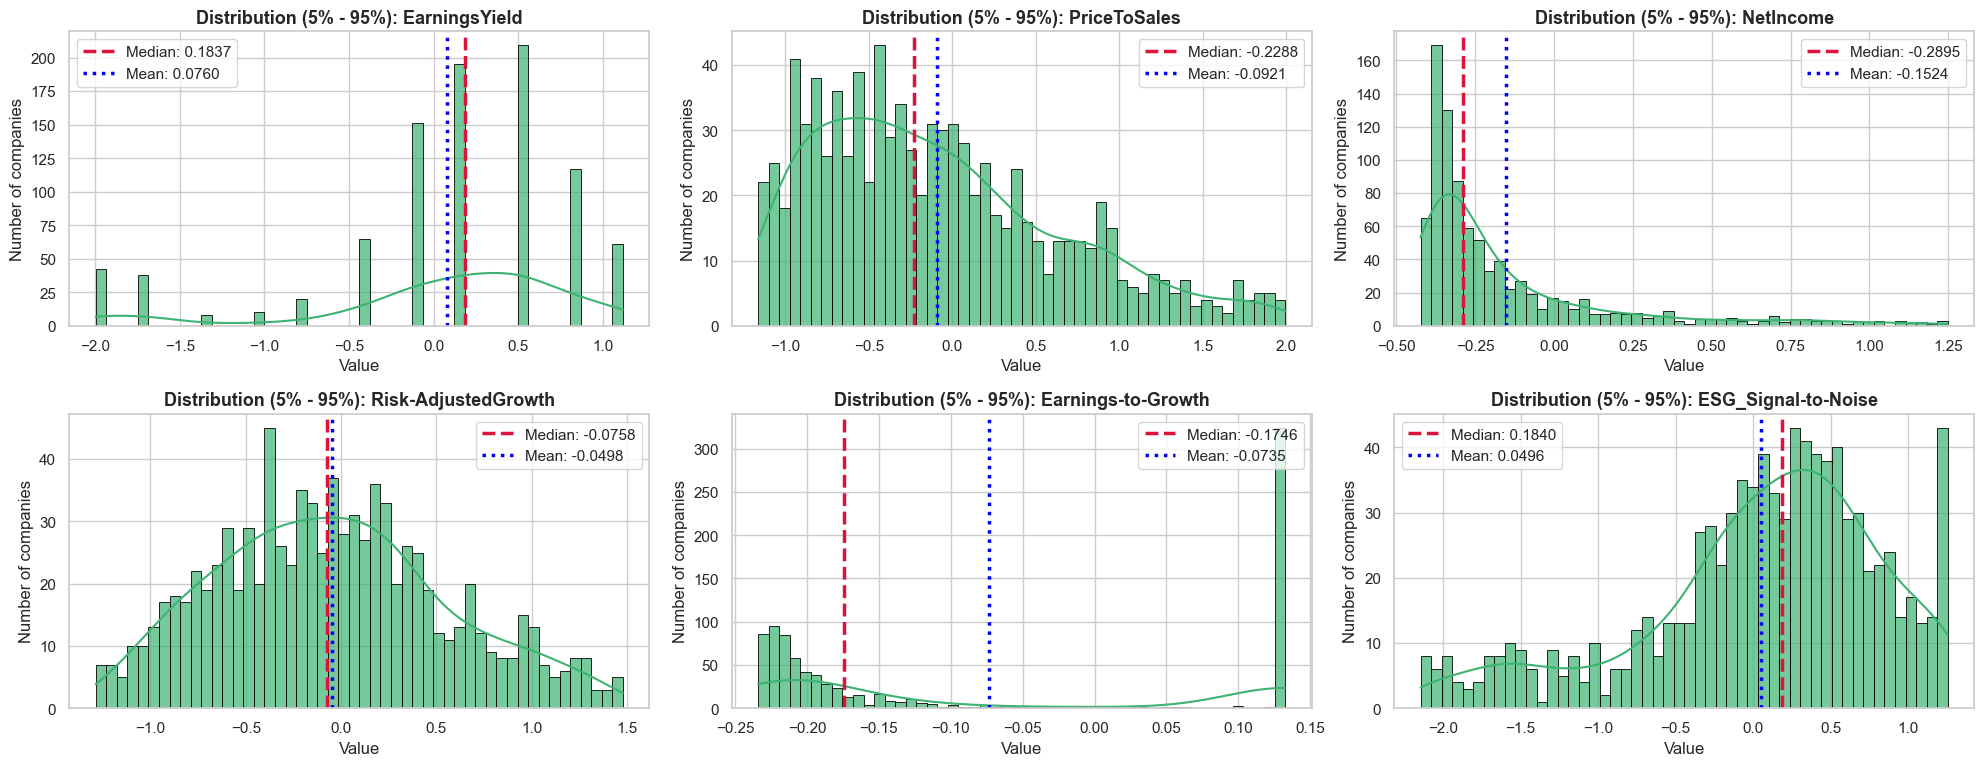

In [18]:
# Dokładniejsza analiza problematycznych kolumn
problematic_columns = ['EarningsYield', 'PriceToSales', 'NetIncome', 'Risk-AdjustedGrowth', 'Earnings-to-Growth', 'ESG_Signal-to-Noise']
plt.figure(figsize=(20, 15))

for i, col in enumerate(problematic_columns, 1):
    plt.subplot(4, 3, i)

    q_low = df[col].quantile(0.05)
    q_high = df[col].quantile(0.95)
    
    filtered_data = df[(df[col] >= q_low) & (df[col] <= q_high)][col]
    sns.histplot(filtered_data, kde=True, bins=50, color="mediumseagreen", edgecolor="black", alpha=0.7)
    median_val = filtered_data.median()
    mean_val = filtered_data.mean()

    plt.axvline(median_val, color='crimson', linestyle='--', linewidth=2.5, label=f'Median: {median_val:.4f}')
    plt.axvline(mean_val, color='blue', linestyle=':', linewidth=2.5, label=f'Mean: {mean_val:.4f}')
    plt.title(f'Distribution (5% - 95%): {col}', fontsize=13, fontweight='bold')
    plt.xlabel('Value')
    plt.ylabel('Number of companies')
    plt.legend()

plt.tight_layout()
plt.show()